#### In this lab, we will build and train a Convolutional Neural Network (CNN) using Keras and TensorFlow for the Fashion MNIST dataset, which consists of grayscale images of fashion items. 

Steps: 

#### Import Libraries:
- keras and tensorflow are deep learning libraries.
- matplotlib.pyplot, numpy
- fashion_mnist from keras.datasets to load the Fashion MNIST dataset.
- Sequential, Dense, Dropout, Conv2D, MaxPooling2D, and Flatten are different layers used to build the CNN.

#### Load and Visualize the Dataset:
- Load the Fashion MNIST dataset and define class names.
- Visualize the first 50 images from the training set with their corresponding labels.

#### Preprocess the Data:
- Reshape the images to have a single channel (grayscale) and normalize pixel values to the range [0, 1].
- Convert labels to one-hot encoded vectors.

#### Build the CNN Model:
- Create a sequential model.
- Add two convolutional layers with ReLU activation.
- Add a max-pooling layer to reduce spatial dimensions.
- Add dropout layers to prevent overfitting.
- Flatten the output and add a dense hidden layer with ReLU activation.
- Add another dropout layer.
- Finally, add the output layer with softmax activation for classification.

#### Compile and Train the Model:
- Compile the model using categorical cross-entropy loss and the Adam optimizer.

#### Train the model on the training data for 5 epochs.
- Plot Training History:
- Plot the training and validation loss over epochs.

#### Confusion Matrix:
- Evaluate the model on the validation set and create a confusion matrix.

#### Model Visualization:
- Save an architecture diagram of the model to a file.

#### Misclassified Images:
- Identify and visualize misclassified images from the validation set.

#### Save the Model:
- Save the trained model to a file named 'fashionmnist_cnn.keras'.

Additionaly, we will do a confusion matrix plot function (plot_confusion_matrix) using SKLEARN and plot misclassified images with their predictions and actual labels.

### Import Libraries (keras, tensorflow, numpy, matplotlib) 

In [1]:
import keras
import tensorflow as tf
import numpy as np
from matplotlib import pyplot as plt

#### from keras libraries, import mnist, Sequential, Dense, Dropout, Conv2D, MaxPooling2D, and Flatten

In [2]:
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.layers import Conv2D, MaxPooling2D
from keras.layers import Flatten

#### import the fashion_mnist dataset from keras.datasets

In [3]:
from keras.datasets import fashion_mnist

#### Load the data using these variables: (X_train, y_train), (X_valid, y_valid)

In [4]:
(X_train, y_train), (X_valid, y_valid) = fashion_mnist.load_data()

#### select a sample of an image
feel free to use: np.random.randint (0, X_train.shape[0])

In [5]:
sample = np.random.randint (0, X_train.shape[0])

#### Plot the sample image

In [7]:
sample

29463

#### Rename the labels (class_names) 
#### from (0,1,2,3...,9) to ('T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot')

In [9]:
class_names = {
    0: 'T-shirt/top',
    1: 'Trouser',
    2: 'Pullover',
    3: 'Dress',
    4: 'Coat',
    5: 'Sandal',
    6: 'Shirt',
    7: 'Sneaker',
    8: 'Bag',
    9: 'Ankle boot' 
}

#### Plot some images showing the new label

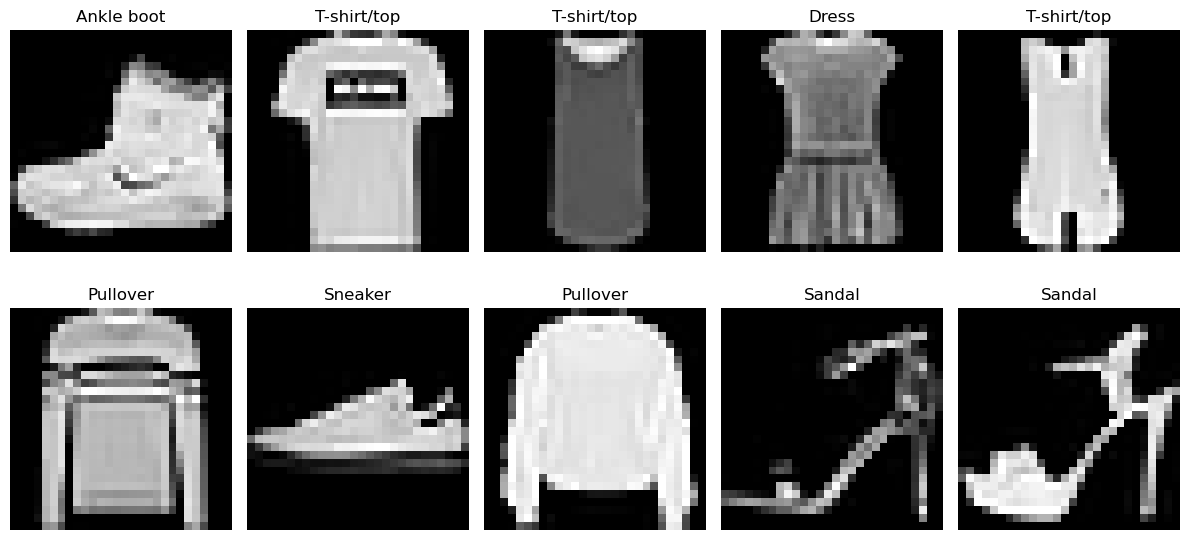

In [13]:
num_images=10
images = X_train[:num_images]
labels = y_train[:num_images]
plt.figure(figsize=(12, 6))
for i in range(num_images):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(class_names[labels[i]])
    plt.axis('off')

plt.tight_layout()
plt.show()

## Convolutional Neural Network in Keras

### Preprocess data

- Reshape the imanges (X_train and X_valid) to the original 28x28-pixel format. 
  - You should have four parameters: (number of availabe values, 28, 28, and the digit that represents the number of colors).
- Also, use the astype() method to specify the data type as ('float32') to convert the pixel darknesses from integers into single-precision float values for both X_train and X_valid.

In [16]:
X_train = X_train.reshape((-1, 28, 28, 1)).astype('float32')
X_valid = X_valid.reshape((-1, 28, 28, 1)).astype('float32')

### Convert the pixel intergers to floats by dividing the variables X_train and X_valid by 255

In [17]:
X_train /= 255
X_valid /= 255

### Convert the label y (y_train,y_valid) from integers into one-hot encodings
n_classes = 10 <br> for y_train and y_valid, use tf.keras.utils.to_categorical

In [18]:
n_classes = 10
y_train = tf.keras.utils.to_categorical(y_train, n_classes)
y_valid = tf.keras.utils.to_categorical(y_valid, n_classes)

### Design the Convolutional Neural Network architecture

- Create a Sequential model and call it "model"
- For the first convolutional layer, use the add() method with 32 filters, kernel_size of 3x3, activation relu, and the correct input shape with three parameters (28,28,1).
- For the second convolutional layer, use the add() method with 64 filters, kernel_size of 3x3, and activation relu.
- Add MaxPooling2D with a pool size of (2x2) to reduce computational complexity.
- Add dropout 30% to reduce overfitting 
- Using Flatten, convert the three dimensional activation map output by conv2D() to a one dimensional array.
- add a dense hidden layer with 128 neurons with relu activation function
- and dropout of 40% 
- add an output layer with 10 neurons, n_classes = 10, and activation function softmax

In [20]:
model = Sequential()

#First convolutional layer
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))

#Second convolutional layer
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))

#Add MaxPooling2D
model.add(MaxPooling2D(pool_size=(2, 2)))

#Add dropout 30%
model.add(Dropout(0.30))

#Using Flatten
model.add(Flatten())

#Add a dense hidden layer
model.add(Dense(128, activation='relu'))

#Dropout of 40%
model.add(Dropout(0.40))

#Add output layer
model.add(Dense(n_classes, activation='softmax'))

### Display the summary of the model

In [21]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           (None, 26, 26, 32)        320       
                                                                 
 conv2d_3 (Conv2D)           (None, 24, 24, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 12, 12, 64)       0         
 2D)                                                             
                                                                 
 dropout_2 (Dropout)         (None, 12, 12, 64)        0         
                                                                 
 flatten_1 (Flatten)         (None, 9216)              0         
                                                                 
 dense_1 (Dense)             (None, 128)               1179776   
                                                      

#### Compile the model with the followign parameters:
- loss="categorical_crossentropy"
- Optimizer adam
- Set the metrics to 'accuracy' to recieve feedbak on model accurancy

In [23]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

### Train the model (model.fit) with the followign parameters:
- X_train 
- y_train 
- batch_size=64
- epochs=5 
- verbose=1 
- validation_data=(X_valid, y_valid))

In [24]:
model.fit(X_train, y_train, batch_size=64, epochs=5, verbose=1, validation_data=(X_valid, y_valid))

Epoch 1/5
938/938 [==============================] - 89s 93ms/step - loss: 0.4705 - accuracy: 0.8318 - val_loss: 0.3151 - val_accuracy: 0.8853
Epoch 2/5
938/938 [==============================] - 86s 92ms/step - loss: 0.3090 - accuracy: 0.8898 - val_loss: 0.2814 - val_accuracy: 0.8967
Epoch 3/5
938/938 [==============================] - 91s 97ms/step - loss: 0.2576 - accuracy: 0.9061 - val_loss: 0.2529 - val_accuracy: 0.9097
Epoch 4/5
938/938 [==============================] - 87s 93ms/step - loss: 0.2285 - accuracy: 0.9164 - val_loss: 0.2380 - val_accuracy: 0.9138
Epoch 5/5
938/938 [==============================] - 83s 89ms/step - loss: 0.2047 - accuracy: 0.9243 - val_loss: 0.2293 - val_accuracy: 0.9177


#### Plot the Model loss

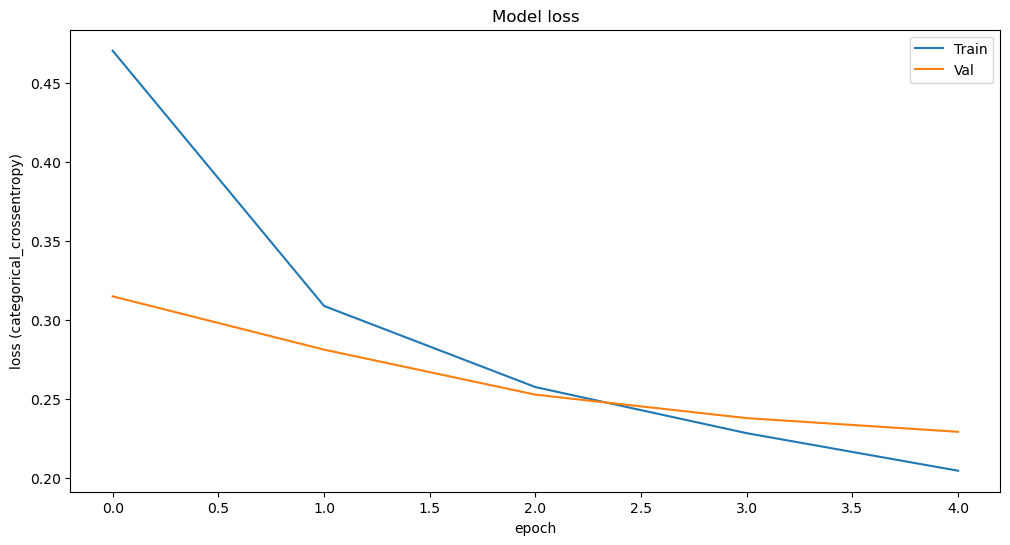

In [25]:
plt.figure(figsize=(12,6))
plt.plot(model.history.history['loss'][:])
plt.plot(model.history.history['val_loss'][:])
plt.title('Model loss')
plt.xlabel('epoch')
plt.ylabel('loss (categorical_crossentropy)')
plt.legend(['Train', 'Val'], loc='upper right')

### Evaluate the model (loss and accuracy)

In [26]:
loss, accuracy = model.evaluate(X_valid, y_valid)

313/313 [==============================] - 4s 13ms/step - loss: 0.2293 - accuracy: 0.9177


### Create a function to prin the confusion matrix
#### Feel free to use the code form your first lab, the one below, or your own code. 

### Import Libraries   
- From collections input Counter
- Import confusion_matrix from sklearn
- import itertoos

In [29]:
from collections import Counter
from sklearn.metrics import confusion_matrix
import itertools

#### For the confusion matrix, define a function:

def plot_confusion_matrix(cm, classes,<br>
                          normalize=False,<br>
                          title='Confusion matrix', <br>
                          cmap=plt.cm.Blues):

In [30]:
# Look at confusion matrix 
#Note, this code is taken straight from the SKLEARN website, an nice way of viewing confusion matrix.
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('Observacion')
    plt.xlabel('Prediccion')

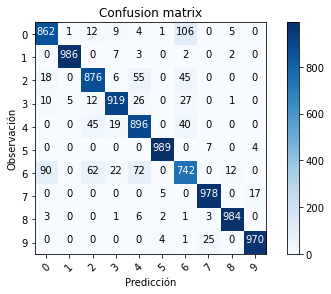

In [21]:
# Predict the values from the validation dataset
Y_pred = model.predict(X_valid)
# Convert predictions classes to one hot vectors 
Y_pred_classes = np.argmax(Y_pred, axis = 1) 
# Convert validation observations to one hot vectors
Y_true = np.argmax(y_valid, axis = 1) 
# compute the confusion matrix
confusion_mtx = confusion_matrix(Y_true, Y_pred_classes) 
# plot the confusion matrix
plot_confusion_matrix(confusion_mtx, classes = range(10))

#### Review the value of accuracy that you obtained in the first assignment (Using a Shallow Neural Network) and compare it to the value obtained using the Convolutional Neural Network. 
### What model performed better CNN or ANN?

The first assignment the loss was 0.4390 with an accuracy of .8427.  This assignment was loss: 0.2293 - accuracy: 0.9177.
Loss
Lower loss indicates better alignment between predictions and true values. This has significantly lower loss (0.2293 vs. 0.4390), which suggests it is making predictions closer to the ground truth.
Accuracy
Higher accuracy indicates more correct classifications overall. This model has a much higher accuracy (91.77% vs. 80%), which is a substantial improvement.

#### Add a variable called predictions = model.predict(X_valid)

In [31]:
predictions = model.predict(X_valid)

313/313 [==============================] - 4s 13ms/step


#### Using X_valid, reshape, and a for loop, find out how many incorrect predictions are. Store them in a variable called: <br>incorrect_predictions = [ ]

In [32]:
images = X_valid.reshape((10000, 28, 28))
incorrect_predictions = []

for i, (p, e) in enumerate(zip(predictions, y_valid)):
    predicted, expected = np.argmax(p), np.argmax(e)
    
    if predicted != expected:
        incorrect_predictions.append((i, images[i], predicted, expected))

#### Print the length of (incorrect_predictions)

In [33]:
len(incorrect_predictions)

823

#### Plot the incorrect predictions

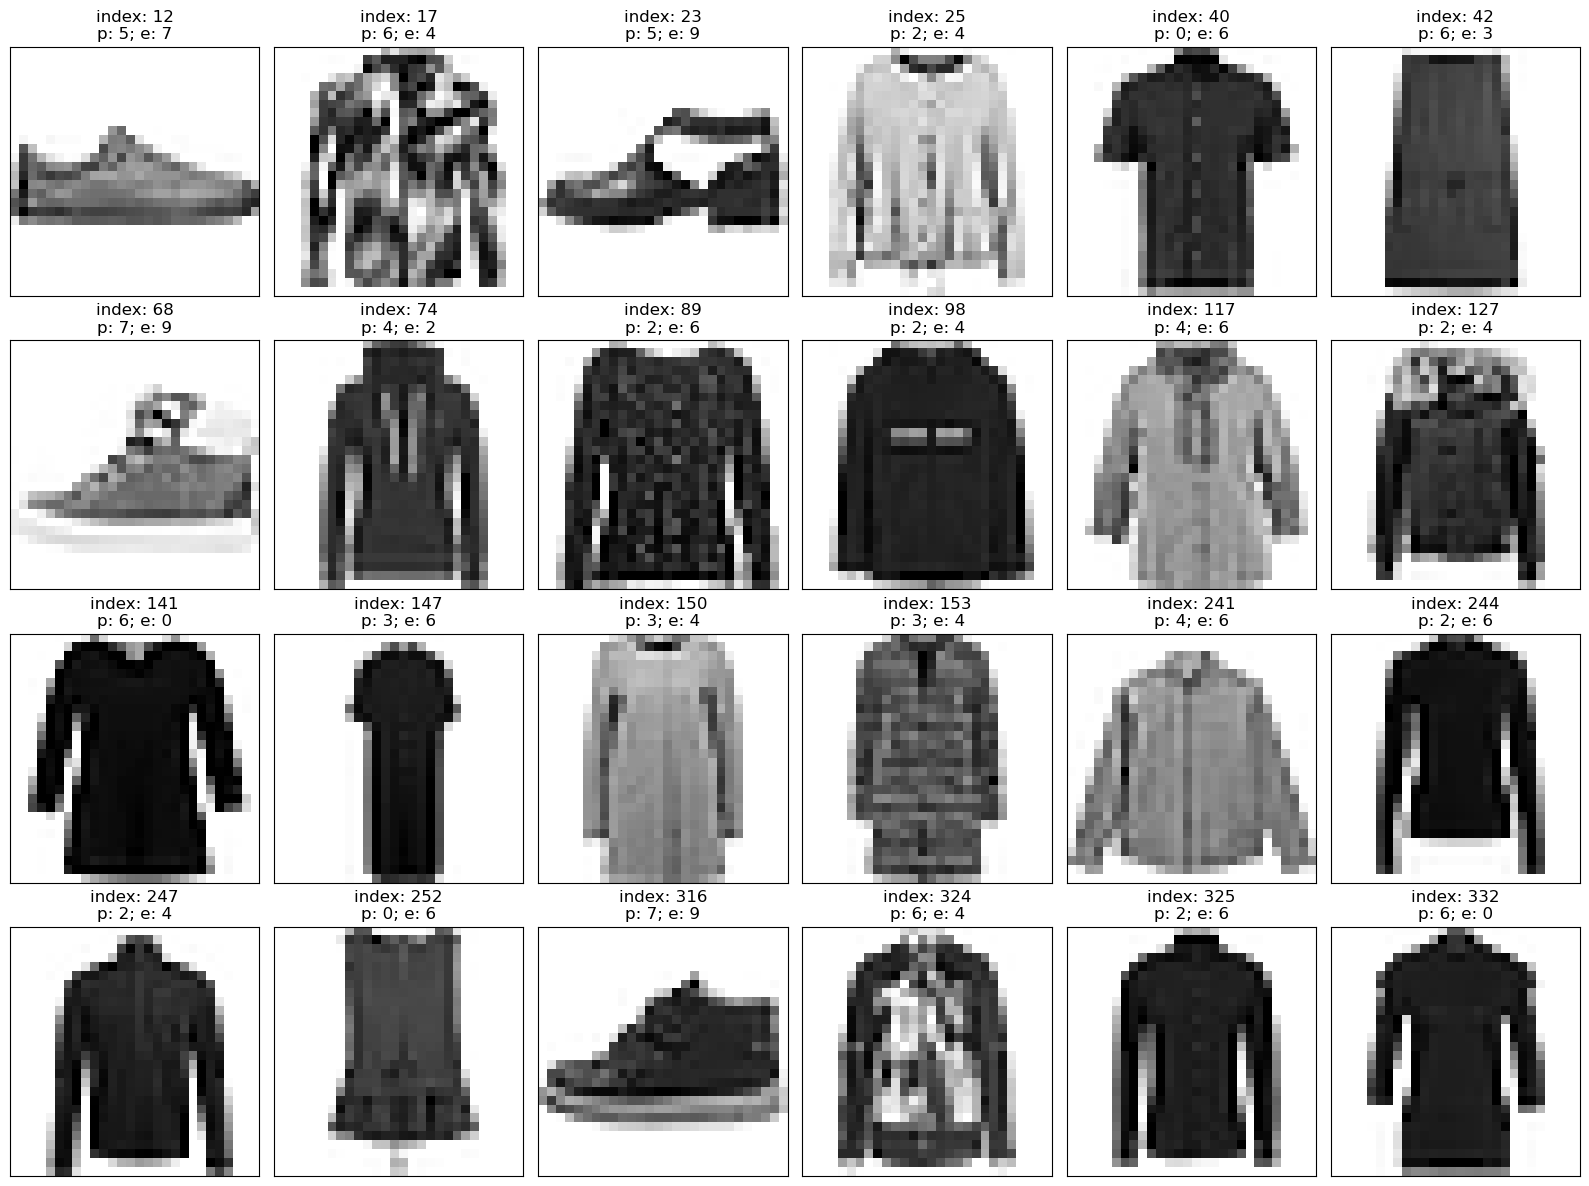

In [34]:
figure, axes = plt.subplots(nrows=4, ncols=6, figsize=(16, 12))

for axes, item in zip(axes.ravel(), incorrect_predictions):
    index, image, predicted, expected = item
    axes.imshow(image, cmap=plt.cm.gray_r)
    axes.set_xticks([])  # remove x-axis tick marks
    axes.set_yticks([])  # remove y-axis tick marks
    axes.set_title(f'index: {index}\np: {predicted}; e: {expected}')
plt.tight_layout()

#### Save your model as fashionmnist_cnn.keras

In [35]:
model.save('fashionmnist_cnn.keras')